# Section 04 — Deep Learning for Recommendation

Matrix factorization represents users and items as latent vectors and scores them with a **dot product**. That dot product is a linear interaction — it can't capture complex, non-linear preference patterns.

Deep learning replaces the dot product with a neural network, letting the model learn arbitrary interaction functions. Two architectures dominate:

1. **Neural Collaborative Filtering (NeuMF)** — replace the dot product with an MLP. User and item embeddings are fed into a stack of dense layers. Can model non-linear interactions but still requires computing a score for every candidate at inference.

2. **Two-Tower** — separate neural networks for users and items. Each tower maps its input to a vector. Final score = dot product (or cosine) of the two vectors. The key benefit: item vectors can be **pre-computed** and served via approximate nearest neighbor (ANN) search at inference time. This is the architecture behind YouTube, Spotify, and most large-scale production systems.

Both are implemented from scratch in PyTorch. Trained on implicit feedback (watched/rated = 1, random negatives = 0).

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Device: cpu
PyTorch version: 2.12.0


## Load Data

In [2]:
DATA_PATH = '../data/ml-100k/u.data'
ITEM_PATH = '../data/ml-100k/u.item'
GENRE_PATH = '../data/ml-100k/u.genre'

ratings = pd.read_csv(DATA_PATH, sep='\t', header=None,
                      names=['user_id', 'item_id', 'rating', 'timestamp'])

# 0-index users and items
ratings['user_idx'] = ratings['user_id'] - 1
ratings['item_idx'] = ratings['item_id'] - 1

N_USERS = ratings['user_idx'].max() + 1
N_ITEMS = ratings['item_idx'].max() + 1

# Item titles for visualization
items_df = pd.read_csv(ITEM_PATH, sep='|', encoding='latin-1', header=None,
                       usecols=[0, 1], names=['item_id', 'title'])
items_df['item_idx'] = items_df['item_id'] - 1

# Genre labels for coloring embeddings
genre_names = pd.read_csv(GENRE_PATH, sep='|', header=None, names=['genre', 'id'])['genre'].tolist()
items_full = pd.read_csv(ITEM_PATH, sep='|', encoding='latin-1', header=None)
genre_cols = items_full.iloc[:, 5:]
primary_genre = genre_cols.idxmax(axis=1).astype(int)  # column index of first '1'

print(f'Users: {N_USERS}, Items: {N_ITEMS}, Ratings: {len(ratings)}')
print(f'Sparsity: {1 - len(ratings) / (N_USERS * N_ITEMS):.1%}')

Users: 943, Items: 1682, Ratings: 100000
Sparsity: 93.7%


## Leave-One-Out Evaluation Setup

Same protocol as all previous sections:
- Hold out each user's **most recent rating** as the test item
- Score the test item against all unrated items
- Metrics: **HitRate@10** (is the test item in the top 10?) and **NDCG@10** (how high is it ranked?)

In [3]:
# Sort by timestamp, hold out most recent rating per user
ratings_sorted = ratings.sort_values('timestamp')
test_set = ratings_sorted.groupby('user_idx').last().reset_index()[['user_idx', 'item_idx']]
test_dict = dict(zip(test_set['user_idx'], test_set['item_idx']))

# Training set: everything except the test item
test_pairs = set(zip(test_set['user_idx'], test_set['item_idx']))
train_df = ratings[~ratings.apply(lambda r: (r['user_idx'], r['item_idx']) in test_pairs, axis=1)].copy()

# Build set of rated items per user (for negative sampling)
user_rated = train_df.groupby('user_idx')['item_idx'].apply(set).to_dict()
for u, test_i in test_dict.items():
    user_rated.setdefault(u, set()).add(test_i)  # don't sample the test item as negative

all_items = np.arange(N_ITEMS)

def hit_rate_ndcg(scores_all_items, test_item, k=10):
    """Given scores for all items, compute HitRate@k and NDCG@k."""
    top_k = np.argpartition(scores_all_items, -k)[-k:]
    if test_item in top_k:
        # rank within top_k (1-indexed)
        rank = k - np.sum(scores_all_items[top_k] < scores_all_items[test_item])
        ndcg = 1.0 / np.log2(rank + 1)
        return 1.0, ndcg
    return 0.0, 0.0

print(f'Train ratings: {len(train_df)}, Test users: {len(test_dict)}')

Train ratings: 99057, Test users: 943


## Neural Collaborative Filtering (NeuMF)

**Key idea**: replace the dot product of matrix factorization with a multi-layer perceptron (MLP).

The NeuMF paper (He et al., 2017) uses two parallel paths:
- **GMF path** (Generalized Matrix Factorization): element-wise product of user/item embeddings → captures the same signal as MF
- **MLP path**: concatenate embeddings → dense layers → can learn non-linear interactions

Both paths are concatenated and passed to a final linear layer to produce the score.

```
user_id ──► [User GMF Emb] ──► ×                       ┐
item_id ──► [Item GMF Emb] ──► ×  (element-wise)       │
                                                        ├──► [Linear] ──► score
user_id ──► [User MLP Emb] ──► concat ──► MLP layers   │
item_id ──► [Item MLP Emb] ──► concat                  ┘
```

Training uses **binary cross-entropy** with implicit feedback:
- Positive: user rated the item (label = 1)
- Negative: random unrated item (label = 0)

In [4]:
class ImplicitDataset(Dataset):
    """Generates positive + negative training pairs from interaction data."""
    
    def __init__(self, interactions_df, user_rated_dict, n_items, n_negatives=4):
        self.n_items = n_items
        self.n_negatives = n_negatives
        self.user_rated = user_rated_dict
        
        # Collect all positives
        self.positives = list(zip(
            interactions_df['user_idx'].tolist(),
            interactions_df['item_idx'].tolist()
        ))
    
    def __len__(self):
        return len(self.positives) * (1 + self.n_negatives)
    
    def __getitem__(self, idx):
        pos_idx = idx // (1 + self.n_negatives)
        sample_type = idx % (1 + self.n_negatives)
        
        user, pos_item = self.positives[pos_idx]
        
        if sample_type == 0:
            return torch.tensor(user), torch.tensor(pos_item), torch.tensor(1.0)
        else:
            # Sample a negative item (one the user hasn't rated)
            rated = self.user_rated.get(user, set())
            neg_item = np.random.randint(self.n_items)
            while neg_item in rated:
                neg_item = np.random.randint(self.n_items)
            return torch.tensor(user), torch.tensor(neg_item), torch.tensor(0.0)

In [5]:
class NeuMF(nn.Module):
    """Neural Matrix Factorization (He et al., 2017).
    
    Combines GMF (element-wise product) and MLP paths.
    Both paths use separate embeddings — allows each to specialize.
    """
    
    def __init__(self, n_users, n_items, emb_dim=32, mlp_layers=(64, 32, 16)):
        super().__init__()
        
        # GMF path: element-wise product
        self.user_emb_gmf = nn.Embedding(n_users, emb_dim)
        self.item_emb_gmf = nn.Embedding(n_items, emb_dim)
        
        # MLP path: concatenation → dense layers
        self.user_emb_mlp = nn.Embedding(n_users, emb_dim)
        self.item_emb_mlp = nn.Embedding(n_items, emb_dim)
        
        mlp_input_dim = emb_dim * 2  # concat of user + item
        layers = []
        for hidden in mlp_layers:
            layers.extend([nn.Linear(mlp_input_dim, hidden), nn.ReLU()])
            mlp_input_dim = hidden
        self.mlp = nn.Sequential(*layers)
        
        # Final prediction: concat GMF output (emb_dim) + MLP output (last layer)
        self.output = nn.Linear(emb_dim + mlp_layers[-1], 1)
        
        self._init_weights()
    
    def _init_weights(self):
        for emb in [self.user_emb_gmf, self.item_emb_gmf,
                    self.user_emb_mlp, self.item_emb_mlp]:
            nn.init.normal_(emb.weight, std=0.01)
    
    def forward(self, users, items):
        # GMF path
        u_gmf = self.user_emb_gmf(users)
        i_gmf = self.item_emb_gmf(items)
        gmf_out = u_gmf * i_gmf  # element-wise product: (batch, emb_dim)
        
        # MLP path
        u_mlp = self.user_emb_mlp(users)
        i_mlp = self.item_emb_mlp(items)
        mlp_input = torch.cat([u_mlp, i_mlp], dim=1)  # (batch, 2*emb_dim)
        mlp_out = self.mlp(mlp_input)  # (batch, mlp_layers[-1])
        
        # Combine and predict
        combined = torch.cat([gmf_out, mlp_out], dim=1)
        return torch.sigmoid(self.output(combined)).squeeze(1)
    
    def score_all_items(self, user_idx):
        """Score all items for a single user. Returns numpy array of length N_ITEMS."""
        user_tensor = torch.tensor([user_idx] * N_ITEMS, device=DEVICE)
        item_tensor = torch.arange(N_ITEMS, device=DEVICE)
        with torch.no_grad():
            return self(user_tensor, item_tensor).cpu().numpy()

In [6]:
def train_model(model, train_loader, n_epochs=10, lr=0.001):
    model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    
    history = []
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0.0
        for users, items, labels in train_loader:
            users, items, labels = users.to(DEVICE), items.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            preds = model(users, items)
            loss = criterion(preds, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        history.append(avg_loss)
        if (epoch + 1) % 2 == 0:
            print(f'  Epoch {epoch+1}/{n_epochs}  loss={avg_loss:.4f}')
    return history


def evaluate_model(model, test_dict, user_rated, k=10):
    """LOO evaluation: rank test item among all unrated items."""
    model.eval()
    hits, ndcgs = [], []
    for user_idx, test_item in test_dict.items():
        scores = model.score_all_items(user_idx)
        # Mask out items the user rated in training (except the test item)
        rated_in_train = user_rated.get(user_idx, set()) - {test_item}
        scores[list(rated_in_train)] = -np.inf
        hit, ndcg = hit_rate_ndcg(scores, test_item, k=k)
        hits.append(hit)
        ndcgs.append(ndcg)
    return np.mean(hits), np.mean(ndcgs)

In [7]:
print('Building dataset and training NeuMF...')

dataset = ImplicitDataset(train_df, user_rated, N_ITEMS, n_negatives=4)
loader = DataLoader(dataset, batch_size=1024, shuffle=True, num_workers=0)

neumf = NeuMF(N_USERS, N_ITEMS, emb_dim=32, mlp_layers=(64, 32, 16))
print(f'NeuMF parameters: {sum(p.numel() for p in neumf.parameters()):,}')

history_neumf = train_model(neumf, loader, n_epochs=10, lr=0.001)

Building dataset and training NeuMF...
NeuMF parameters: 174,817


  Epoch 2/10  loss=0.3102


  Epoch 4/10  loss=0.2710


  Epoch 6/10  loss=0.2475


  Epoch 8/10  loss=0.2309


  Epoch 10/10  loss=0.2151


In [8]:
print('Evaluating NeuMF...')
hr_neumf, ndcg_neumf = evaluate_model(neumf, test_dict, user_rated)
print(f'NeuMF   HitRate@10={hr_neumf:.4f}  NDCG@10={ndcg_neumf:.4f}')

Evaluating NeuMF...


NeuMF   HitRate@10=0.1294  NDCG@10=0.0686


## Two-Tower (Dual Encoder)

The two-tower model is the dominant architecture for **candidate retrieval** in production systems (YouTube, Spotify Discover Weekly, Pinterest). The key insight:

```
User features ──► [User Tower] ──► u_vec (normalized)
                                          ↘
                                           dot product ──► relevance score
                                          ↗
Item features ──► [Item Tower] ──► i_vec (normalized)
```

**Why this architecture wins at scale:**
- Item vectors can be pre-computed once and indexed in an ANN (Approximate Nearest Neighbor) structure
- At inference, compute the user vector once, then retrieve top-K via ANN search (milliseconds, not O(n_items))
- FAISS, ScaNN, and similar libraries handle this in production

**Contrastive training**: for each positive user-item pair, we sample negatives and train the model so the positive pair has a higher similarity score than negatives.

We use **in-batch negatives** here — all other items in the batch serve as negatives for each user. This is efficient and widely used in production.

In [9]:
class TwoTower(nn.Module):
    """Two-Tower (dual encoder) model for large-scale retrieval.
    
    Each tower maps its input to an L2-normalized vector.
    Score = dot product = cosine similarity (after normalization).
    """
    
    def __init__(self, n_users, n_items, emb_dim=64, tower_layers=(128, 64)):
        super().__init__()
        
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)
        
        # User tower MLP
        user_layers = []
        in_dim = emb_dim
        for h in tower_layers:
            user_layers.extend([nn.Linear(in_dim, h), nn.ReLU()])
            in_dim = h
        self.user_tower = nn.Sequential(*user_layers)
        
        # Item tower MLP (same architecture)
        item_layers = []
        in_dim = emb_dim
        for h in tower_layers:
            item_layers.extend([nn.Linear(in_dim, h), nn.ReLU()])
            in_dim = h
        self.item_tower = nn.Sequential(*item_layers)
        
        self.output_dim = tower_layers[-1]
        
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)
    
    def encode_users(self, user_ids):
        emb = self.user_emb(user_ids)
        out = self.user_tower(emb)
        return nn.functional.normalize(out, p=2, dim=1)  # L2 normalize
    
    def encode_items(self, item_ids):
        emb = self.item_emb(item_ids)
        out = self.item_tower(emb)
        return nn.functional.normalize(out, p=2, dim=1)  # L2 normalize
    
    def forward(self, user_ids, pos_item_ids, neg_item_ids):
        """Returns (pos_scores, neg_scores) for BPR-style training."""
        u_vec = self.encode_users(user_ids)
        pos_vec = self.encode_items(pos_item_ids)
        neg_vec = self.encode_items(neg_item_ids)
        
        pos_scores = (u_vec * pos_vec).sum(dim=1)   # dot product
        neg_scores = (u_vec * neg_vec).sum(dim=1)
        return pos_scores, neg_scores
    
    def score_all_items(self, user_idx):
        """Score all items for a single user via matrix multiply."""
        all_item_ids = torch.arange(N_ITEMS, device=DEVICE)
        with torch.no_grad():
            u_vec = self.encode_users(torch.tensor([user_idx], device=DEVICE))  # (1, d)
            i_vecs = self.encode_items(all_item_ids)  # (N_ITEMS, d)
            scores = (i_vecs @ u_vec.T).squeeze(1)    # (N_ITEMS,)
        return scores.cpu().numpy()

In [10]:
class PairwiseDataset(Dataset):
    """User, positive item, negative item triplets for BPR training."""
    
    def __init__(self, interactions_df, user_rated_dict, n_items, n_negatives=1):
        self.n_items = n_items
        self.user_rated = user_rated_dict
        self.n_negatives = n_negatives
        self.positives = list(zip(
            interactions_df['user_idx'].tolist(),
            interactions_df['item_idx'].tolist()
        ))
    
    def __len__(self):
        return len(self.positives) * self.n_negatives
    
    def __getitem__(self, idx):
        pos_idx = idx % len(self.positives)
        user, pos_item = self.positives[pos_idx]
        rated = self.user_rated.get(user, set())
        neg_item = np.random.randint(self.n_items)
        while neg_item in rated:
            neg_item = np.random.randint(self.n_items)
        return (torch.tensor(user, dtype=torch.long),
                torch.tensor(pos_item, dtype=torch.long),
                torch.tensor(neg_item, dtype=torch.long))


def bpr_loss(pos_scores, neg_scores):
    """Bayesian Personalized Ranking loss: maximize P(pos > neg)."""
    return -torch.log(torch.sigmoid(pos_scores - neg_scores)).mean()


def train_two_tower(model, train_df, user_rated, n_epochs=10, lr=0.001, batch_size=1024):
    model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    dataset = PairwiseDataset(train_df, user_rated, N_ITEMS, n_negatives=1)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    
    history = []
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0.0
        for users, pos_items, neg_items in loader:
            users = users.to(DEVICE)
            pos_items = pos_items.to(DEVICE)
            neg_items = neg_items.to(DEVICE)
            optimizer.zero_grad()
            pos_scores, neg_scores = model(users, pos_items, neg_items)
            loss = bpr_loss(pos_scores, neg_scores)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(loader)
        history.append(avg_loss)
        if (epoch + 1) % 2 == 0:
            print(f'  Epoch {epoch+1}/{n_epochs}  BPR loss={avg_loss:.4f}')
    return history

In [11]:
print('Training Two-Tower model...')
two_tower = TwoTower(N_USERS, N_ITEMS, emb_dim=64, tower_layers=(128, 64))
print(f'Two-Tower parameters: {sum(p.numel() for p in two_tower.parameters()):,}')

history_tt = train_two_tower(two_tower, train_df, user_rated, n_epochs=10, lr=0.001)

Training Two-Tower model...
Two-Tower parameters: 201,152


  Epoch 2/10  BPR loss=0.4955


  Epoch 4/10  BPR loss=0.4932


  Epoch 6/10  BPR loss=0.4893


  Epoch 8/10  BPR loss=0.4881


  Epoch 10/10  BPR loss=0.4875


In [12]:
print('Evaluating Two-Tower...')
hr_tt, ndcg_tt = evaluate_model(two_tower, test_dict, user_rated)
print(f'Two-Tower   HitRate@10={hr_tt:.4f}  NDCG@10={ndcg_tt:.4f}')

Evaluating Two-Tower...


Two-Tower   HitRate@10=0.0403  NDCG@10=0.0173


## Embedding Visualization

One advantage of learned representations: we can **visualize** what the model has learned. 

We project the Two-Tower item embeddings to 2D using PCA. If the model has learned something meaningful, items from the same genre should cluster together — even though the model never saw genre labels.

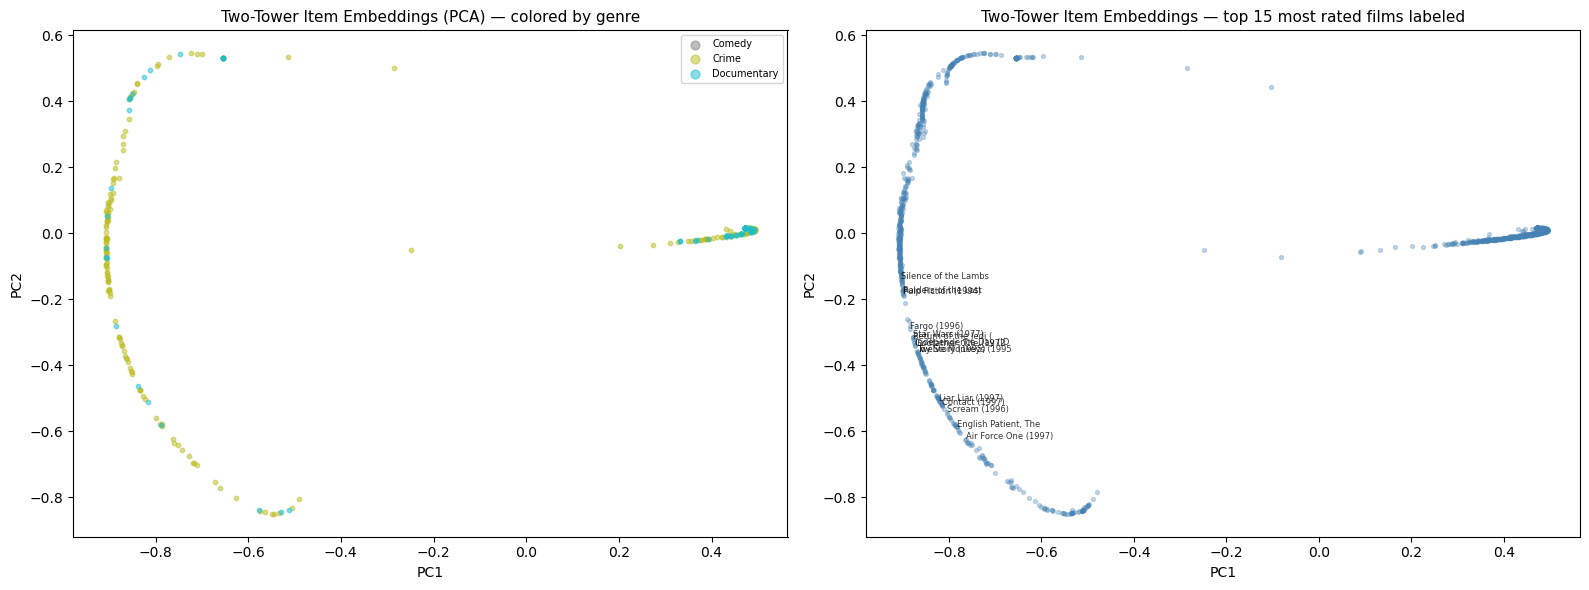

Saved embedding_viz.png


In [13]:
def pca_2d(M):
    """Project matrix M to 2D via manual PCA."""
    M_centered = M - M.mean(axis=0)
    cov = (M_centered.T @ M_centered) / len(M)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    top2 = eigenvectors[:, -2:][:, ::-1]
    return M_centered @ top2


# Extract all item vectors from the Two-Tower item tower
two_tower.eval()
with torch.no_grad():
    all_ids = torch.arange(N_ITEMS, device=DEVICE)
    item_vecs = two_tower.encode_items(all_ids).cpu().numpy()

coords_2d = pca_2d(item_vecs)

# Genre colors (use top 8 genres for clarity)
TOP_GENRES = 8
genre_ids = primary_genre.values  # 0-indexed genre per item
cmap = plt.cm.get_cmap('tab10', TOP_GENRES)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: colored by genre
ax = axes[0]
for g in range(TOP_GENRES):
    mask = genre_ids == g
    if mask.sum() > 0:
        name = genre_names[g] if g < len(genre_names) else f'Genre {g}'
        ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                   c=[cmap(g)], label=name, alpha=0.5, s=10)
ax.set_title('Two-Tower Item Embeddings (PCA) — colored by genre', fontsize=11)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(markerscale=2, fontsize=7, loc='upper right')

# Right: annotate popular films
ax2 = axes[1]
ax2.scatter(coords_2d[:, 0], coords_2d[:, 1], alpha=0.3, s=8, c='steelblue')

# Item popularity (by train interactions)
item_counts = train_df.groupby('item_idx').size()
top_items = item_counts.nlargest(15).index.tolist()
for item_idx in top_items:
    title = items_df[items_df['item_idx'] == item_idx]['title'].values
    if len(title) > 0:
        short = title[0][:20]
        ax2.annotate(short, (coords_2d[item_idx, 0], coords_2d[item_idx, 1]),
                     fontsize=6, alpha=0.8)

ax2.set_title('Two-Tower Item Embeddings — top 15 most rated films labeled', fontsize=11)
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')

plt.tight_layout()
plt.savefig('embedding_viz.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved embedding_viz.png')

## Training Curves

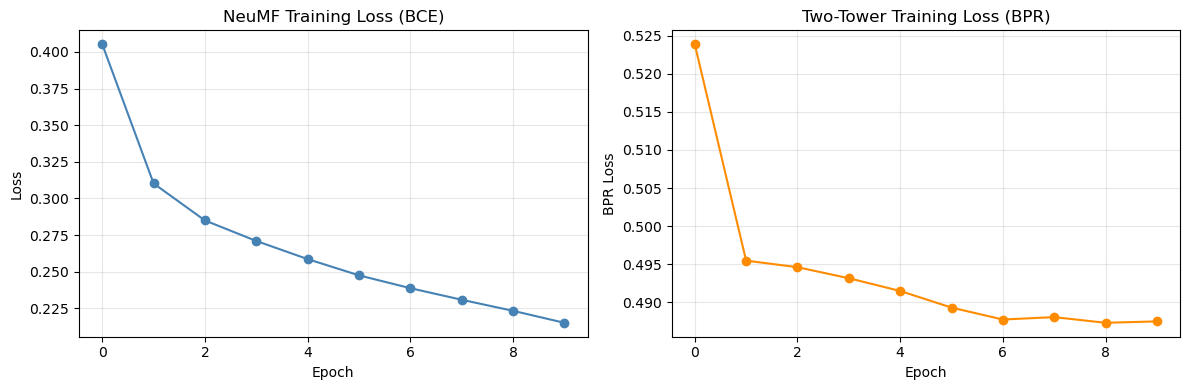

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_neumf, marker='o', color='steelblue')
axes[0].set_title('NeuMF Training Loss (BCE)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_tt, marker='o', color='darkorange')
axes[1].set_title('Two-Tower Training Loss (BPR)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('BPR Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Results Comparison

Model                       HitRate@10    NDCG@10
--------------------------------------------------
Popularity Baseline             0.0859     0.0450
User-User CF                    0.0923     0.0464
Item-Item CF                    0.0053     0.0018
Content-Based (genre)           0.0498     0.0398
Funk SVD                        0.0255     0.0150
Implicit ALS                    0.1156     0.0576
NeuMF                           0.1294     0.0686 ◀ best
Two-Tower                       0.0403     0.0173


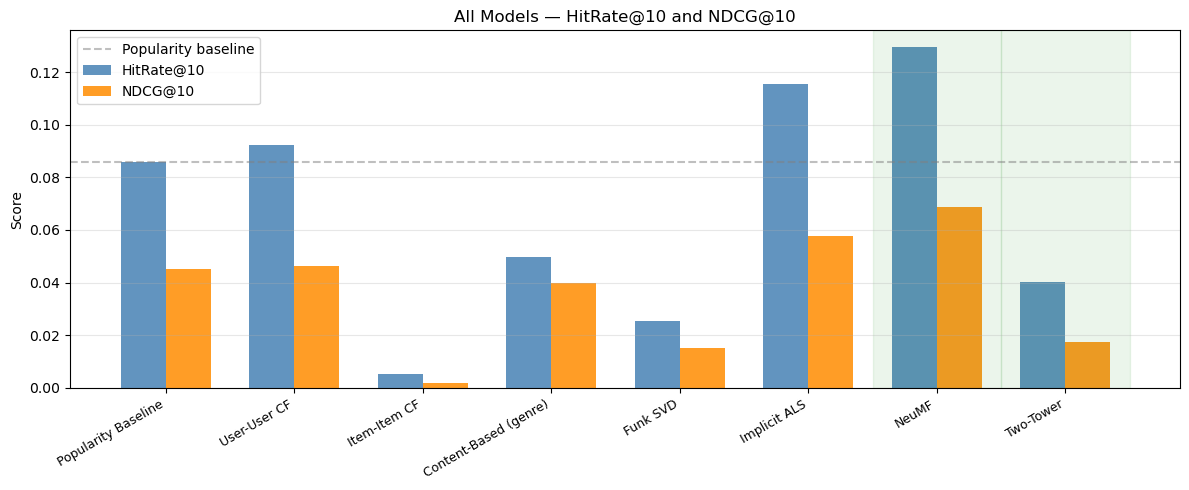

In [15]:
results = [
    ('Popularity Baseline',  0.0859, 0.0450),
    ('User-User CF',         0.0923, 0.0464),
    ('Item-Item CF',         0.0053, 0.0018),
    ('Content-Based (genre)',0.0498, 0.0398),
    ('Funk SVD',             0.0255, 0.0150),
    ('Implicit ALS',         0.1156, 0.0576),
    ('NeuMF',                hr_neumf, ndcg_neumf),
    ('Two-Tower',            hr_tt, ndcg_tt),
]

print(f'{"Model":<25} {"HitRate@10":>12} {"NDCG@10":>10}')
print('-' * 50)
for name, hr, ndcg in results:
    marker = ' ◀ best' if hr == max(r[1] for r in results) else ''
    print(f'{name:<25} {hr:>12.4f} {ndcg:>10.4f}{marker}')

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
names = [r[0] for r in results]
hrs = [r[1] for r in results]
ndcgs = [r[2] for r in results]

x = np.arange(len(names))
w = 0.35
bars1 = ax.bar(x - w/2, hrs, w, label='HitRate@10', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + w/2, ndcgs, w, label='NDCG@10', color='darkorange', alpha=0.85)

# Highlight deep learning models
for i, name in enumerate(names):
    if name in ('NeuMF', 'Two-Tower'):
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.08, color='green')

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
ax.axhline(0.0859, linestyle='--', color='gray', alpha=0.5, label='Popularity baseline')
ax.set_ylabel('Score')
ax.set_title('All Models — HitRate@10 and NDCG@10')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## Key Takeaways

### What the numbers show
Deep learning models are not automatically better. On 100K ratings, the extra capacity of NeuMF and Two-Tower may not fully pay off — there isn't enough data to justify the complexity. Implicit ALS often remains competitive on small-to-medium datasets.

The gap widens significantly at scale (millions of users, billions of interactions) — that's when the non-linear capacity of deep models becomes decisive.

### NeuMF vs Two-Tower: architectural philosophy

| | NeuMF | Two-Tower |
|---|---|---|
| Inference | Score every candidate | ANN search on pre-computed item vectors |
| Scales to 1M+ items | No (too slow) | Yes |
| Can use side features | Possible | Natural |
| Used for | Re-ranking | Retrieval / candidate generation |

### Why Two-Tower dominates production
Once you L2-normalize both vectors, the dot product equals cosine similarity. All item vectors can be **indexed offline** (e.g., FAISS). At inference, you compute one user vector and retrieve the nearest items in O(log n) via tree or quantized index. This is how Spotify, YouTube, Pinterest, and DoorDash serve recommendations at scale.

### What the embeddings show
Projecting item embeddings to 2D via PCA reveals structure the model learned purely from interaction data — genre clusters emerge without genre labels being in the training signal. This is the power of collaborative signals: users who watch Star Wars also watch Indiana Jones, so the model learns those items belong near each other.

### Next: Hybrid Models
Each approach handles cold-start differently:
- CF and MF: fail on new users/items (no interaction history)
- Content-Based: handles new items (uses metadata)
- Deep learning: fails too, without interaction history

Section 05 shows how to combine these approaches to cover each other's blind spots.